In [29]:
from pathlib import Path

MODEL_PATH = Path("models/checkpoint_epoch_1.pth")

Load model

In [30]:
import torch
from torchvision.models import efficientnet_b0
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model = checkpoint['model']
model_types = checkpoint['all_types']
model = model.to(device)
model.eval()

print(f"Model was trained on {len(model_types)} creature types")

Model was trained on 65 creature types


Read data

In [31]:
import pandas as pd

df = pd.read_csv(f"data/oracle_cards_manifest.csv")
print(f"Total cards: {len(df)}")
print(df.head())
print(df["types"].value_counts().head(20))

Total cards: 10466
                        illustration_id          types  \
0  7106ab4f-bd3e-4d2a-ba9c-7f223b5a0b7f      Elf|Druid   
1  d01aa92b-0582-4e1e-a7b0-737b2ad4e462           Bird   
2  6624d93a-e99c-4db8-adab-f11f66e7acfe  Human|Warrior   
3  630d978c-8352-4eeb-86c3-e91f02092276   Insect|Druid   
4  980e6255-6258-4359-94f4-5ed79fe23cdf          Human   

                         name  \
0    Nissa, Worldsoul Speaker   
1                  Storm Crow   
2   Greta, Sweettooth Scourge   
3               Nantuko Elder   
4  Hua Tuo, Honored Physician   

                                          image_path  
0  data\oracle_cards\7106ab4f-bd3e-4d2a-ba9c-7f22...  
1  data\oracle_cards\d01aa92b-0582-4e1e-a7b0-737b...  
2  data\oracle_cards\6624d93a-e99c-4db8-adab-f11f...  
3  data\oracle_cards\630d978c-8352-4eeb-86c3-e91f...  
4  data\oracle_cards\980e6255-6258-4359-94f4-5ed7...  
types
Human|Soldier      511
Human|Wizard       505
Spirit             391
Elemental          336
Beast

Build dataset

In [32]:
from PIL import Image
from torch.utils.data import Dataset
import torch


class CreatureDataset(Dataset):
    def __init__(self, df, all_types, transform=None):
        self.df = df.reset_index(drop=True)
        self.all_types = all_types
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        label = torch.zeros(len(self.all_types))
        types = row["types"].split("|") if isinstance(row["types"], str) else []
        for t in types:
            if t in self.all_types:
                label[self.all_types.index(t)] = 1.0
        
        return image, label

In [33]:
all_types = sorted(set(
    t for types_str in df["types"] if isinstance(types_str, str) for t in types_str.strip().split("|")
))
print(all_types)
print(f"amount of creature types:", len(all_types))

['Advisor', 'Ally', 'Angel', 'Artificer', 'Assassin', 'Avatar', 'Beast', 'Berserker', 'Bird', 'Cat', 'Cleric', 'Construct', 'Demon', 'Dinosaur', 'Dog', 'Dragon', 'Drake', 'Druid', 'Dwarf', 'Elemental', 'Elf', 'Faerie', 'Giant', 'Goblin', 'Golem', 'Horror', 'Human', 'Insect', 'Knight', 'Lizard', 'Merfolk', 'Noble', 'Ogre', 'Phyrexian', 'Pirate', 'Rogue', 'Scout', 'Shaman', 'Shapeshifter', 'Sliver', 'Snake', 'Soldier', 'Spirit', 'Treefolk', 'Vampire', 'Wall', 'Warlock', 'Warrior', 'Wizard', 'Wurm', 'Zombie']
amount of creature types: 51


In [34]:
model_types_set = set(model_types)

def is_compatible(types_str):
    if not isinstance(types_str, str):
        return True  # typeless cards are fine
    return all(t in model_types_set for t in types_str.split("|"))

df_eval = df[df["types"].apply(is_compatible)].reset_index(drop=True)
print(f"Evaluation cards after filtering: {len(df_eval)}")

Evaluation cards after filtering: 10466


In [35]:
from torchvision import transforms
from torch.utils.data import DataLoader

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_dataset = CreatureDataset(df_eval, model_types, transform=val_transform)
eval_loader = DataLoader(eval_dataset, batch_size=64, shuffle=False)

print(f"Evaluation dataset size: {len(eval_dataset)}")

Evaluation dataset size: 10466


Evaluate

In [36]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in eval_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

print(f"Predictions shape: {all_preds.shape}")
print(f"Labels shape: {all_labels.shape}")



Predictions shape: torch.Size([10466, 65])
Labels shape: torch.Size([10466, 65])


In [37]:
# get binary predictions
best_f1 = 0
best_threshold = 0.5
step = 0.01

for i in range(1, 100):
    threshold = i * step
    binary_preds = (all_preds > threshold).float()
    
    tp = ((binary_preds == 1) & (all_labels == 1)).sum().item()
    fp = ((binary_preds == 1) & (all_labels == 0)).sum().item()
    fn = ((binary_preds == 0) & (all_labels == 1)).sum().item()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_binary_preds = binary_preds

print(f"best threshold: {best_threshold:.2f}, best f1: {best_f1:.3f}")
binary_preds = best_binary_preds



best threshold: 0.18, best f1: 0.435


In [38]:
results = []
for i, creature_type in enumerate(model_types):
    tp = ((binary_preds[:, i] == 1) & (all_labels[:, i] == 1)).sum().item()
    fp = ((binary_preds[:, i] == 1) & (all_labels[:, i] == 0)).sum().item()
    fn = ((binary_preds[:, i] == 0) & (all_labels[:, i] == 1)).sum().item()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    results.append({
        'type': creature_type,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': int(all_labels[:, i].sum().item())  # how many true examples
    })

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df.to_string(index=False))

        type  precision   recall       f1  support
       Human   0.565121 0.888818 0.690936     3139
        Bird   0.635294 0.603352 0.618911      358
    Treefolk   0.486667 0.688679 0.570312      106
      Sliver   0.514706 0.630631 0.566802      111
       Drake   0.460432 0.627451 0.531120      102
    Dinosaur   0.423792 0.686747 0.524138      166
       Angel   0.468531 0.553719 0.507576      242
        Wall   0.459119 0.544776 0.498294      134
      Goblin   0.459144 0.523282 0.489119      451
     Merfolk   0.491228 0.476190 0.483592      294
         Dog   0.526316 0.434783 0.476190      115
      Dragon   0.383984 0.588050 0.464596      318
        Wurm   0.435897 0.490385 0.461538      104
       Snake   0.514286 0.415385 0.459574      130
     Vampire   0.436869 0.450521 0.443590      384
        Ally   0.632911 0.337838 0.440529      148
         Elf   0.369064 0.504638 0.426332      539
   Elemental   0.404806 0.438000 0.420749      500
         Cat   0.531792 0.34074

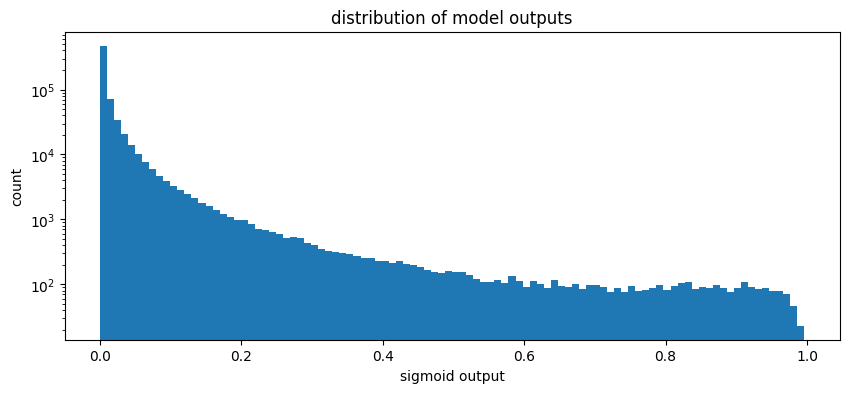

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(all_preds.numpy().flatten(), bins=100)
plt.xlabel("sigmoid output")
plt.ylabel("count")
plt.title("distribution of model outputs")
plt.yscale("log")
plt.show()

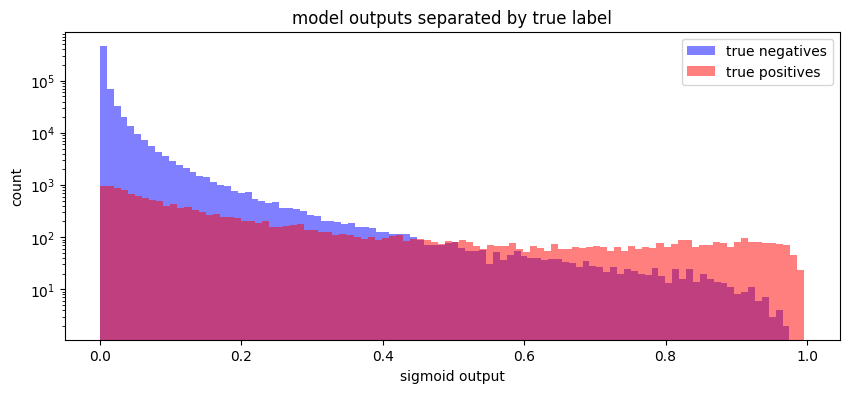

In [40]:
# outputs where the true label is 1 (correct types)
correct_mask = all_labels == 1
incorrect_mask = all_labels == 0

correct_outputs = all_preds[correct_mask].numpy()
incorrect_outputs = all_preds[incorrect_mask].numpy()

plt.figure(figsize=(10, 4))
plt.hist(incorrect_outputs, bins=100, alpha=0.5, label='true negatives', color='blue')
plt.hist(correct_outputs, bins=100, alpha=0.5, label='true positives', color='red')
plt.xlabel("sigmoid output")
plt.ylabel("count")
plt.yscale("log")
plt.legend()
plt.title("model outputs separated by true label")
plt.show()

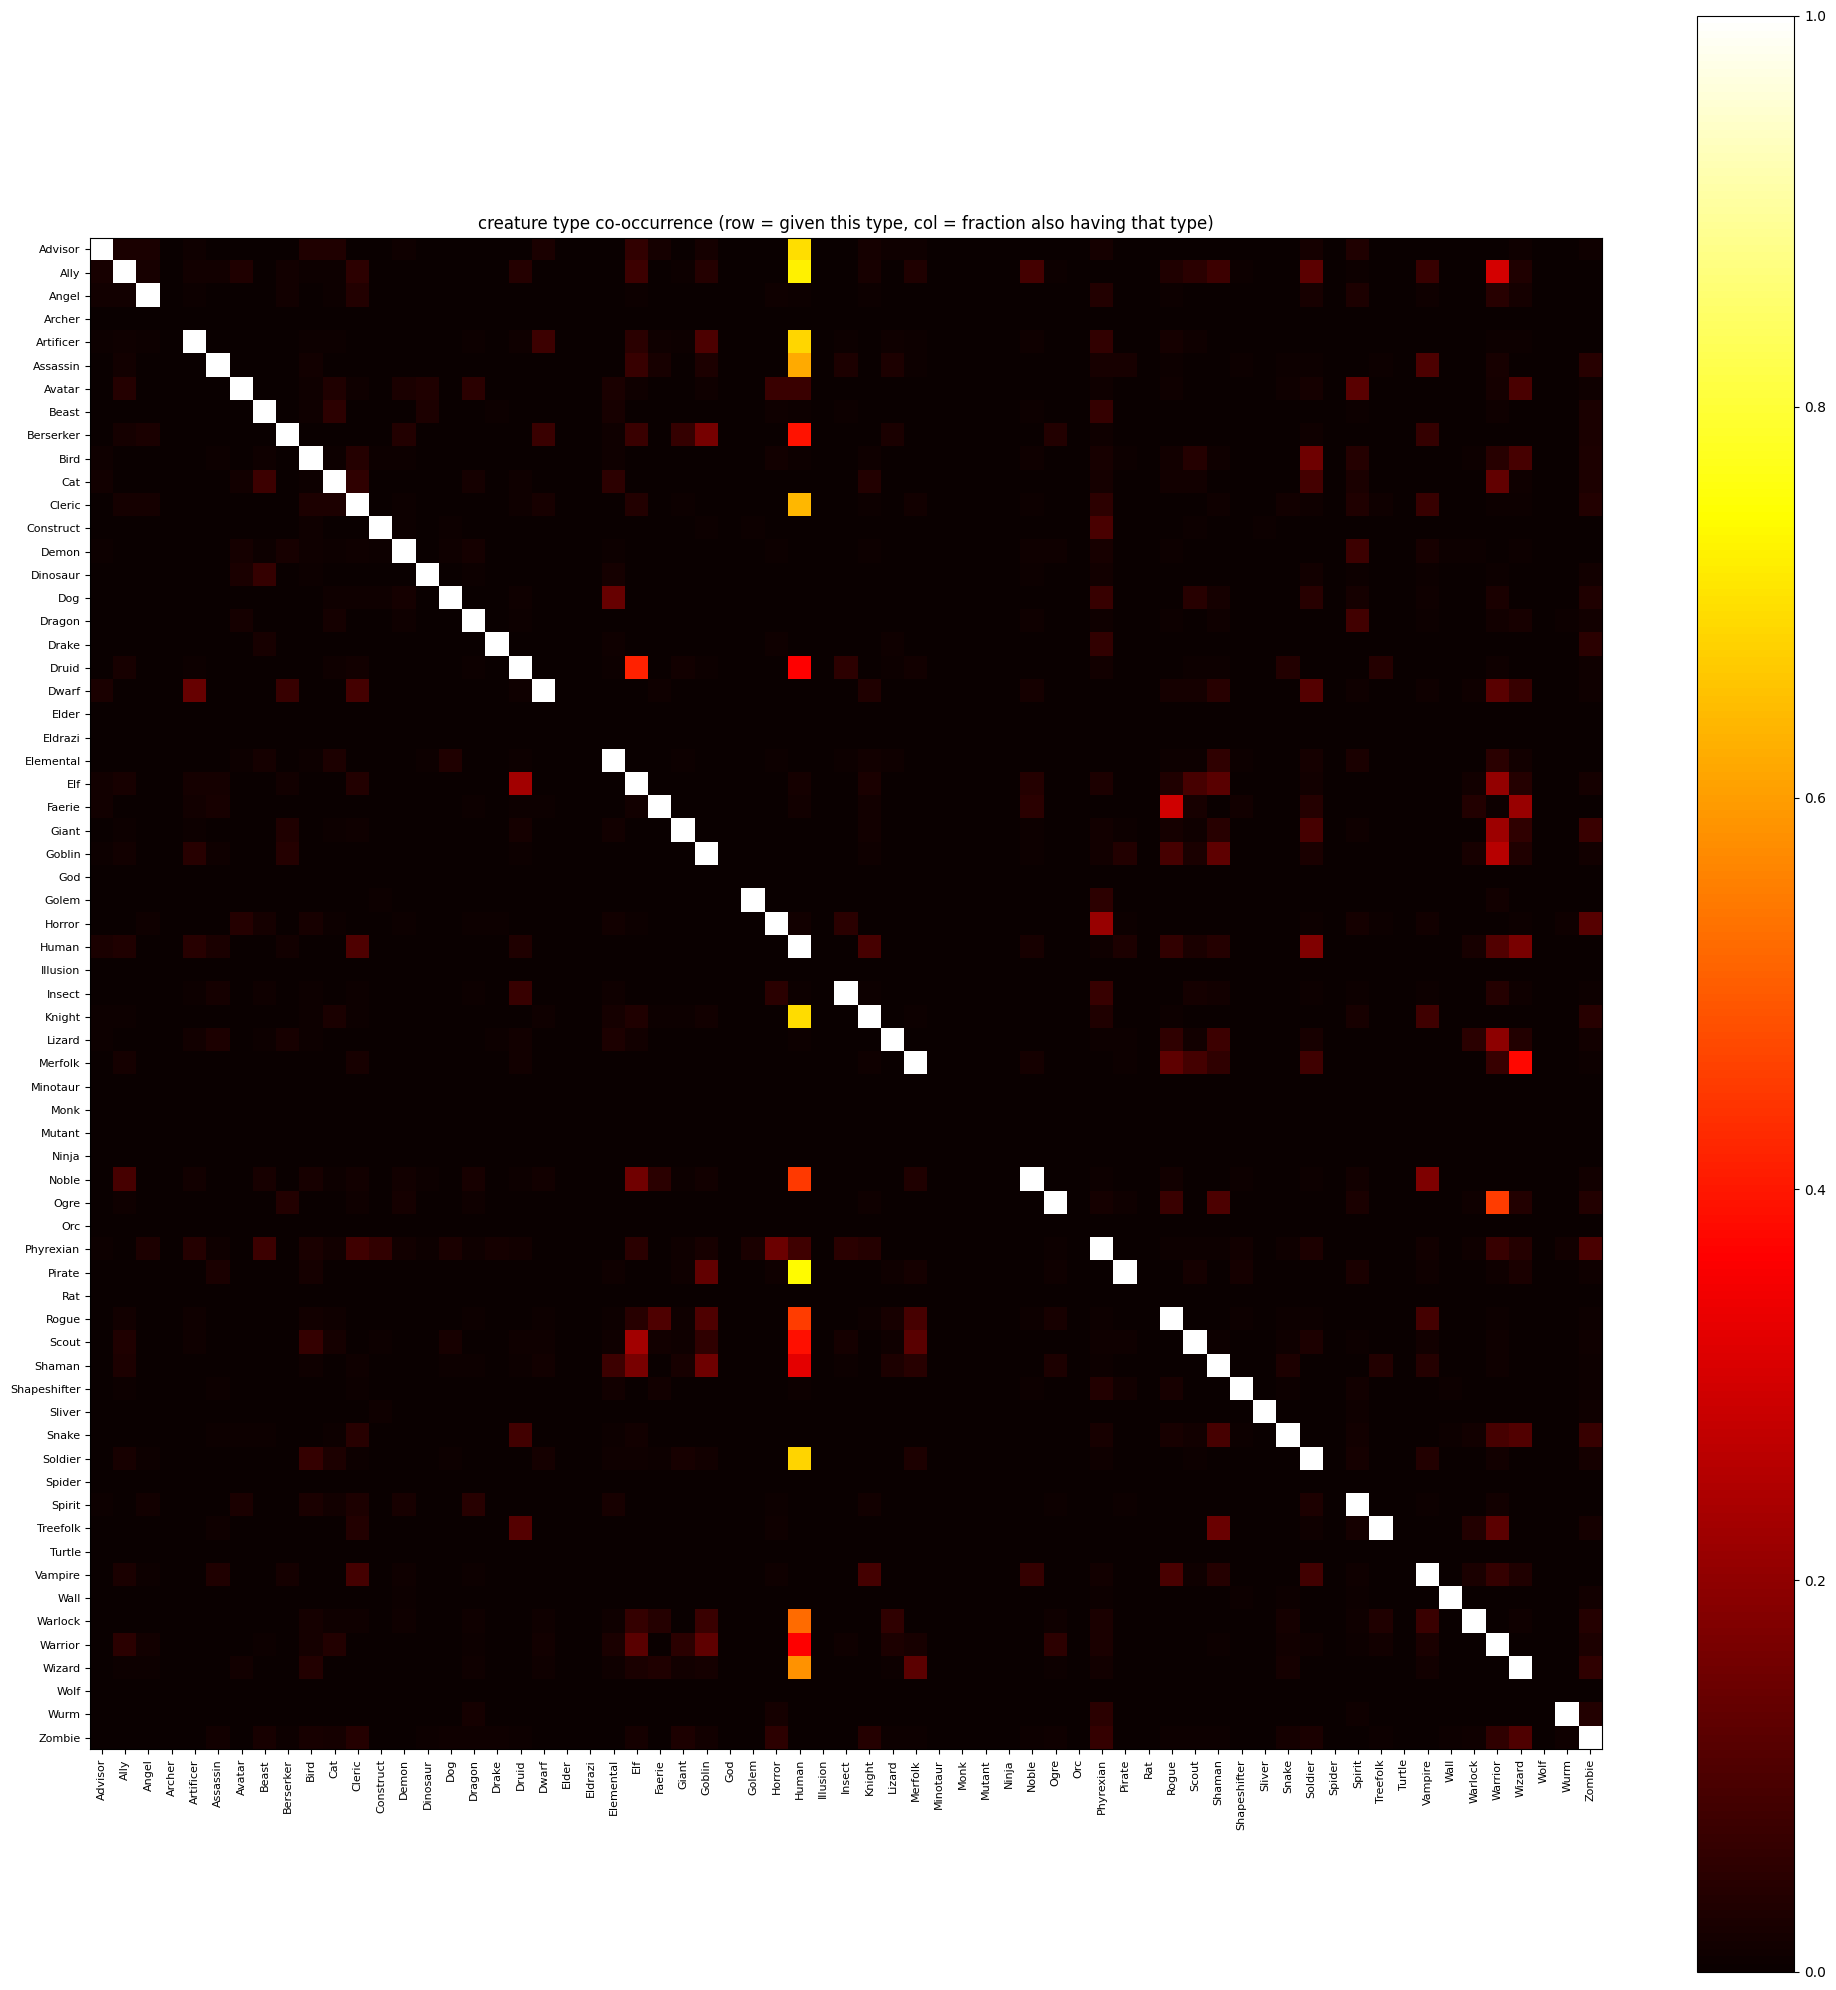

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# compute co-occurrence matrix
n_types = len(model_types)
cooccurrence = np.zeros((n_types, n_types))

labels_np = all_labels.numpy()
for i in range(n_types):
    for j in range(n_types):
        both = (labels_np[:, i] == 1) & (labels_np[:, j] == 1)
        cooccurrence[i, j] = both.sum()

# normalize by diagonal (i.e. what fraction of type i cards also have type j)
normalized = np.zeros((n_types, n_types))
for i in range(n_types):
    if cooccurrence[i, i] > 0:
        normalized[i, :] = cooccurrence[i, :] / cooccurrence[i, i]

fig, ax = plt.subplots(figsize=(20, 20))
im = ax.imshow(normalized, cmap='hot')
ax.set_xticks(range(n_types))
ax.set_yticks(range(n_types))
ax.set_xticklabels(model_types, rotation=90, fontsize=8)
ax.set_yticklabels(model_types, fontsize=8)
plt.colorbar(im)
plt.title("creature type co-occurrence (row = given this type, col = fraction also having that type)")
plt.tight_layout()
plt.show()